# Time-Based Browsing Pattern Analyzer with RAM Usage Correlation

- Autoencoder Anomaly Detection

### Analysis of Personal Browsing Patterns

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os
import warnings
from urllib.parse import urlparse

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

np.random.seed(42)
tf.random.set_seed(42)

print("✓ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ All libraries imported successfully!
TensorFlow version: 2.20.0
Pandas version: 2.3.2


##  Data Loading



In [2]:
# Configuration
SESSION_GAP_MINUTES = 15  # Inactivity threshold for new session

# Create OUTPUT directory
os.makedirs('OUTPUT', exist_ok=True)

print(f"Session gap threshold: {SESSION_GAP_MINUTES} minutes")

Session gap threshold: 15 minutes


In [3]:
# Load browsing history
browsing_df = pd.read_csv('browsing_history.csv')
browsing_df['timestamp'] = pd.to_datetime(browsing_df['timestamp'])

print(f"Browsing data loaded: {len(browsing_df)} records")
print(f"Date range: {browsing_df['timestamp'].min()} to {browsing_df['timestamp'].max()}")
print(f"Time span: {(browsing_df['timestamp'].max() - browsing_df['timestamp'].min()).days} days")



Browsing data loaded: 851 records
Date range: 2026-04-09 13:30:39.513788 to 2026-04-14 06:39:42.435872
Time span: 4 days


In [4]:
ram_df = pd.read_csv('ram_log.csv')
ram_df['timestamp'] = pd.to_datetime(ram_df['timestamp'])

print(f"RAM logs loaded: {len(ram_df)} records")
print(f"Average RAM usage: {ram_df['ram_used_mb'].mean():.2f} MB")
print(f"Average browser RAM: {ram_df['browser_ram_mb'].mean():.2f} MB")

ram_df.head()

RAM logs loaded: 40735 records
Average RAM usage: 8539.60 MB
Average browser RAM: 1067.26 MB


,timestamp,ram_used_mb,ram_available_mb,browser_ram_mb,cpu_percent
0,2026-04-09 13:30:39.513788,10499.34,5500.66,1286.17,46.60
1,2026-04-09 13:30:49.513788,10177.62,5822.38,1331.89,17.80
2,2026-04-09 13:30:59.513788,10715.84,5284.16,1376.74,11.03
3,2026-04-09 13:31:09.513788,10283.82,5716.18,1247.48,19.17
4,2026-04-09 13:31:19.513788,10448.39,5551.61,1108.67,31.60


##  Data Preprocessing



In [5]:
def extract_domain(url):
    """
    Extract domain from URL (privacy-safe, removes query parameters)
    """
    try:
        parsed = urlparse(url)
        domain = parsed.netloc
        # Remove 'www.' prefix
        if domain.startswith('www.'):
            domain = domain[4:]
        return domain
    except:
        return None


browsing_df['domain'] = browsing_df['url'].apply(extract_domain)

# Remove invalid domains
browsing_df = browsing_df.dropna(subset=['domain'])
browsing_df = browsing_df[browsing_df['domain'] != '']

print(f"✓ Cleaned data: {len(browsing_df)} records")
print(f"✓ Unique domains: {browsing_df['domain'].nunique()}")
print("\nTop 20 domains:")
print(browsing_df['domain'].value_counts().head(20))

✓ Cleaned data: 850 records
✓ Unique domains: 20

Top 20 domains:
domain
colab.research.google.com           388
guvi.in                             135
github.com                           88
google.com                           66
chatgpt.com                          29
claude.ai                            29
classify.zenclass.in                 22
docs.google.com                      20
v2.zenclass.in                       19
youtube.com                          16
drive.google.com                     13
docs.aws.amazon.com                   6
hotstar.com                           5
avatars.githubusercontent.com         4
gemini.google.com                     3
console.aws.amazon.com                3
accounts.google.com                   1
forms.gle                             1
eu-north-1.signin.aws.amazon.com      1
portal.aws.amazon.com                 1
Name: count, dtype: int64


✓ Domain categories mapped!

Category distribution:
category
learning          564
development        92
search             66
ai_assistant       61
productivity       34
media              16
cloud_services     11
entertainment       5
authentication      1
Name: count, dtype: int64


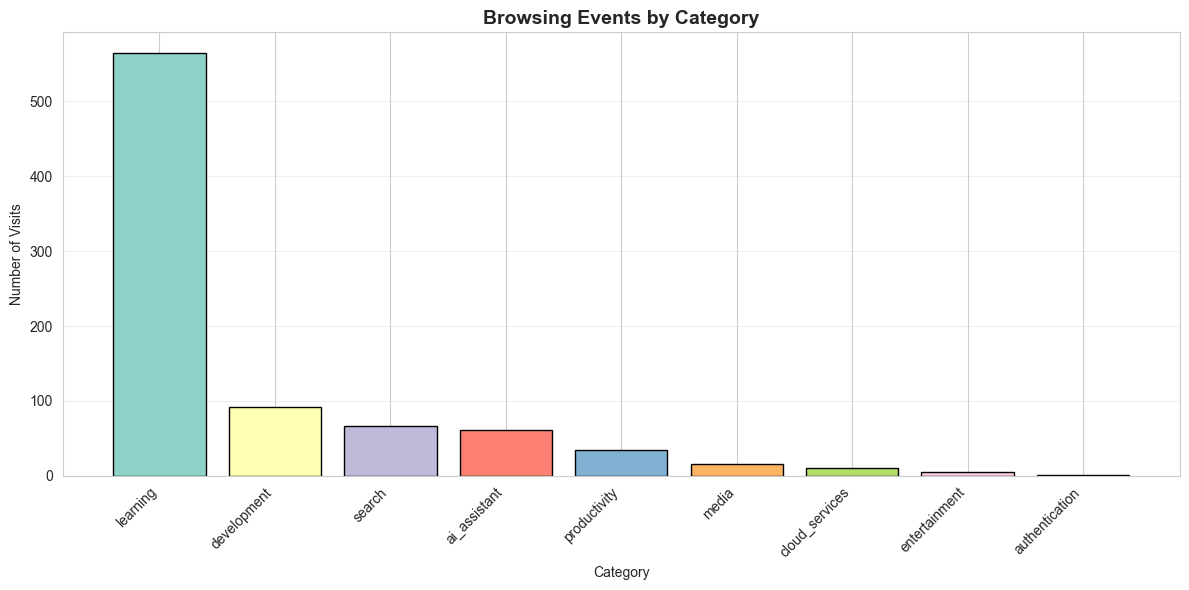


✓ Category distribution saved to OUTPUT/category_distribution.png


In [6]:
domain_category_map = {
    # Learning & Education Platforms
    'guvi.in': 'learning',
    'classify.zenclass.in': 'learning',
    'v2.zenclass.in': 'learning',
    'colab.research.google.com': 'learning',
    
    # Development & Coding
    'github.com': 'development',
    'avatars.githubusercontent.com': 'development',
    
    # AI Assistants
    'chatgpt.com': 'ai_assistant',
    'claude.ai': 'ai_assistant',
    'gemini.google.com': 'ai_assistant',
    
    # Cloud Services (AWS)
    'docs.aws.amazon.com': 'cloud_services',
    'console.aws.amazon.com': 'cloud_services',
    'portal.aws.amazon.com': 'cloud_services',
    'eu-north-1.signin.aws.amazon.com': 'cloud_services',
    
    # Productivity Tools
    'docs.google.com': 'productivity',
    'drive.google.com': 'productivity',
    'forms.gle': 'productivity',
    
    # Media & Entertainment
    'youtube.com': 'media',
    'hotstar.com': 'entertainment',
    
    # Search & General
    'google.com': 'search',
    'accounts.google.com': 'authentication',
}

browsing_df['category'] = browsing_df['domain'].map(domain_category_map)

browsing_df['category'] = browsing_df['category'].fillna('other')

pd.DataFrame(list(domain_category_map.items()), 
             columns=['domain', 'category']).to_csv('OUTPUT/domain_category_map.csv', index=False)

print("✓ Domain categories mapped!")
print("\nCategory distribution:")
print(browsing_df['category'].value_counts())

plt.figure(figsize=(12, 6))
category_counts = browsing_df['category'].value_counts()
colors = plt.cm.Set3(range(len(category_counts)))
plt.bar(range(len(category_counts)), category_counts.values, color=colors, edgecolor='black')
plt.xticks(range(len(category_counts)), category_counts.index, rotation=45, ha='right')
plt.title('Browsing Events by Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Visits')
plt.xlabel('Category')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('OUTPUT/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Category distribution saved to OUTPUT/category_distribution.png")

###  Time-based Features

✓ Time-based features added!

Browsing activity by hour:
hour
2      97
3     121
4     235
5      62
6      59
7       8
10     63
11      1
13     58
14    137
15      9
dtype: int64


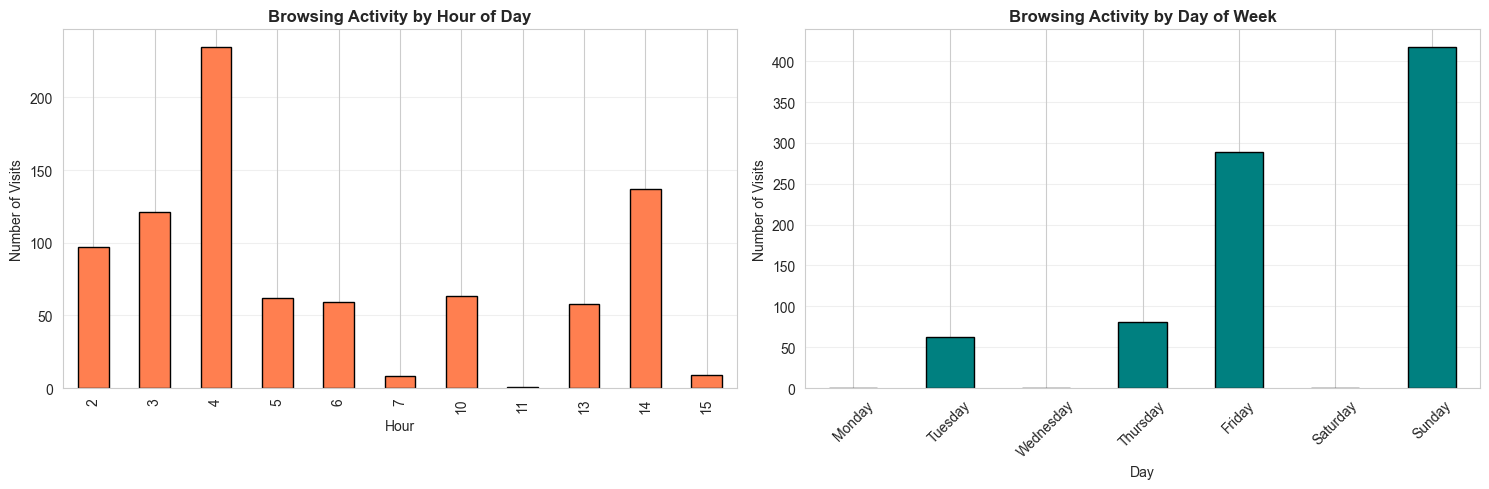


✓ Time patterns saved to OUTPUT/time_patterns.png


In [7]:
browsing_df['hour'] = browsing_df['timestamp'].dt.hour
browsing_df['day_of_week'] = browsing_df['timestamp'].dt.day_name()
browsing_df['date'] = browsing_df['timestamp'].dt.date
browsing_df['is_weekend'] = browsing_df['timestamp'].dt.dayofweek >= 5
browsing_df['day_num'] = browsing_df['timestamp'].dt.dayofweek

def categorize_time_of_day(hour):
    if 0 <= hour < 6:
        return 'night'
    elif 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    else:
        return 'evening'

browsing_df['time_of_day'] = browsing_df['hour'].apply(categorize_time_of_day)

print("✓ Time-based features added!")
print("\nBrowsing activity by hour:")
hourly_activity = browsing_df.groupby('hour').size()
print(hourly_activity)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hourly distribution
hourly_activity.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Browsing Activity by Hour of Day', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Visits')
axes[0].grid(axis='y', alpha=0.3)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = browsing_df['day_of_week'].value_counts().reindex(day_order)
day_counts.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Browsing Activity by Day of Week', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Visits')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('OUTPUT/time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Time patterns saved to OUTPUT/time_patterns.png")

##  Sessionization



✓ Total sessions created: 22
✓ Average events per session: 38.64

Session statistics:
       event_count  unique_domains  duration_minutes
count    22.000000       22.000000         22.000000
mean     38.636364        3.318182         20.936380
std      45.613851        2.417917         20.113086
min       1.000000        1.000000          0.000000
25%       7.250000        1.250000          5.146996
50%      22.500000        2.500000         17.063617
75%      51.750000        4.750000         27.513361
max     172.000000        9.000000         68.690627


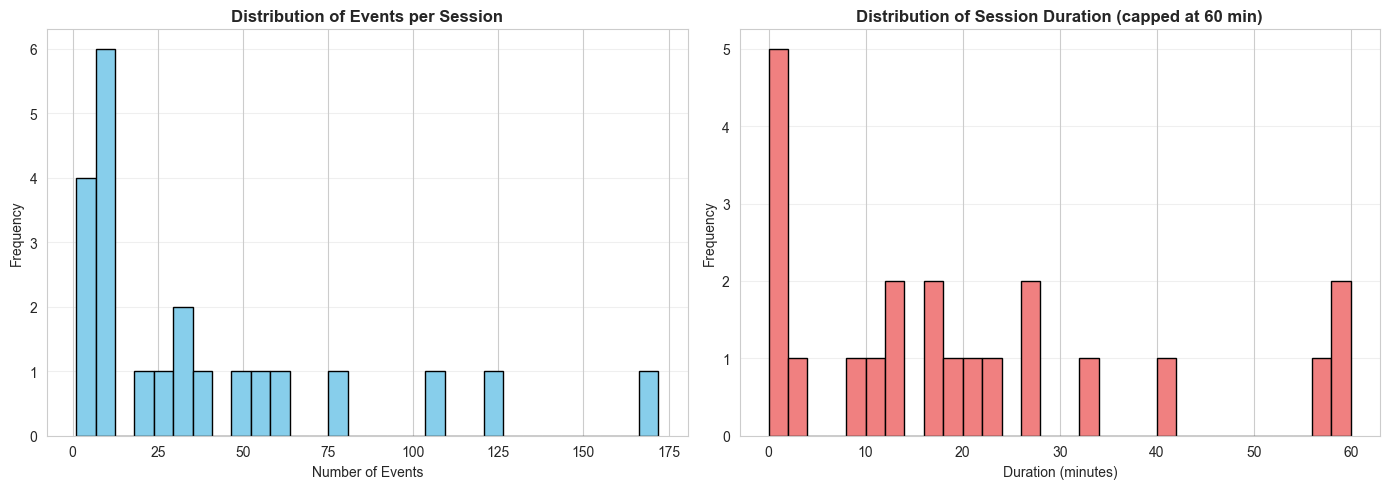


✓ Session statistics saved to OUTPUT/session_statistics.png


In [8]:
def create_sessions(df, gap_minutes=15):
    """
    Create browsing sessions based on time gaps
    """
    df = df.sort_values('timestamp').reset_index(drop=True)
    df['time_diff'] = df['timestamp'].diff()
    df['new_session'] = (df['time_diff'] > pd.Timedelta(minutes=gap_minutes)) | (df['time_diff'].isna())
    df['session_id'] = df['new_session'].cumsum()
    return df


browsing_df = create_sessions(browsing_df, SESSION_GAP_MINUTES)

print(f"✓ Total sessions created: {browsing_df['session_id'].nunique()}")
print(f"✓ Average events per session: {len(browsing_df) / browsing_df['session_id'].nunique():.2f}")

session_stats = browsing_df.groupby('session_id').agg({
    'timestamp': ['min', 'max', 'count'],
    'domain': 'nunique',
    'category': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'mixed'
}).reset_index()

session_stats.columns = ['session_id', 'start_time', 'end_time', 'event_count', 'unique_domains', 'dominant_category']
session_stats['duration_minutes'] = (session_stats['end_time'] - session_stats['start_time']).dt.total_seconds() / 60

print("\nSession statistics:")
print(session_stats[['event_count', 'unique_domains', 'duration_minutes']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(session_stats['event_count'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Events per Session', fontweight='bold')
axes[0].set_xlabel('Number of Events')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(session_stats['duration_minutes'].clip(0, 60), bins=30, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Session Duration (capped at 60 min)', fontweight='bold')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('OUTPUT/session_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Session statistics saved to OUTPUT/session_statistics.png")

### Session Feature Engineering

In [9]:
def create_session_features(browsing_df):
    """
    Create comprehensive features for each session
    """
    session_features = []
    
    for session_id, group in browsing_df.groupby('session_id'):
        start_time = group['timestamp'].min()
        end_time = group['timestamp'].max()
        duration = (end_time - start_time).total_seconds() / 60  # minutes
        
        total_events = len(group)
        unique_domains = group['domain'].nunique()
        unique_categories = group['category'].nunique()
        
        category_counts = group['category'].value_counts()
        total_cat_events = len(group)
        
        features = {
            'session_id': session_id,
            'start_time': start_time,
            'end_time': end_time,
            'duration_minutes': duration,
            'total_events': total_events,
            'unique_domains': unique_domains,
            'unique_categories': unique_categories,
            'events_per_minute': total_events / max(duration, 1),
            'domain_switching_rate': unique_domains / max(total_events, 1),
            'hour': start_time.hour,
            'day_of_week': start_time.day_name(),
            'is_weekend': start_time.dayofweek >= 5,
            'day_num': start_time.dayofweek,
        }
        
        for cat in ['learning', 'development', 'ai_assistant', 'cloud_services', 
                   'productivity', 'media', 'entertainment', 'search', 'authentication']:
            features[f'{cat}_ratio'] = category_counts.get(cat, 0) / total_cat_events
        
        features['other_ratio'] = category_counts.get('other', 0) / total_cat_events
        
        features['dominant_category'] = category_counts.index[0] if len(category_counts) > 0 else 'other'
        
        session_features.append(features)
    
    return pd.DataFrame(session_features)


session_features_df = create_session_features(browsing_df)

print(f"✓ Session features created: {len(session_features_df)} sessions")
print("\nSample session features:")
display_cols = ['session_id', 'duration_minutes', 'total_events', 'dominant_category', 
               'learning_ratio', 'ai_assistant_ratio', 'development_ratio']
print(session_features_df[display_cols].head(10))

✓ Session features created: 22 sessions

Sample session features:
   session_id  duration_minutes  total_events dominant_category  \
0           1          0.948487             2          learning   
1           2         27.941650            77          learning   
2           3          0.044081             2            search   
3           4         33.911124            58          learning   
4           5         58.608774           126          learning   
5           6         22.056733            48          learning   
6           7         17.003184            24             media   
7           8          0.000000             1      ai_assistant   
8           9         40.050720            21            search   
9          10         21.942136            11            search   

   learning_ratio  ai_assistant_ratio  development_ratio  
0        1.000000            0.000000           0.000000  
1        0.597403            0.025974           0.000000  
2        0.000000  

## RAM Correlation Analysis



✓ Merged data: 850 records
✓ Records with RAM data: 850

RAM USAGE BY CATEGORY
                ram_mean   ram_max  ram_std  browser_ram_mean  \
category                                                        
cloud_services  10430.20  10609.38   124.77           1340.42   
search          10178.37  10933.78  1022.13           1258.90   
media            9088.31  10535.31  1843.36           1133.58   
productivity     8108.72  10620.69  2046.51           1071.79   
authentication   6257.31   6257.31      NaN            965.54   
ai_assistant     7372.23  10706.51  1759.27            939.13   
learning         7451.25  10868.00  1731.73            929.46   
development      6730.14  10552.63  1130.00            872.85   
entertainment    6119.29   6401.76   157.91            820.74   

                browser_ram_max  browser_ram_std  event_count  
category                                                       
cloud_services          1500.34            62.76           11  
search       

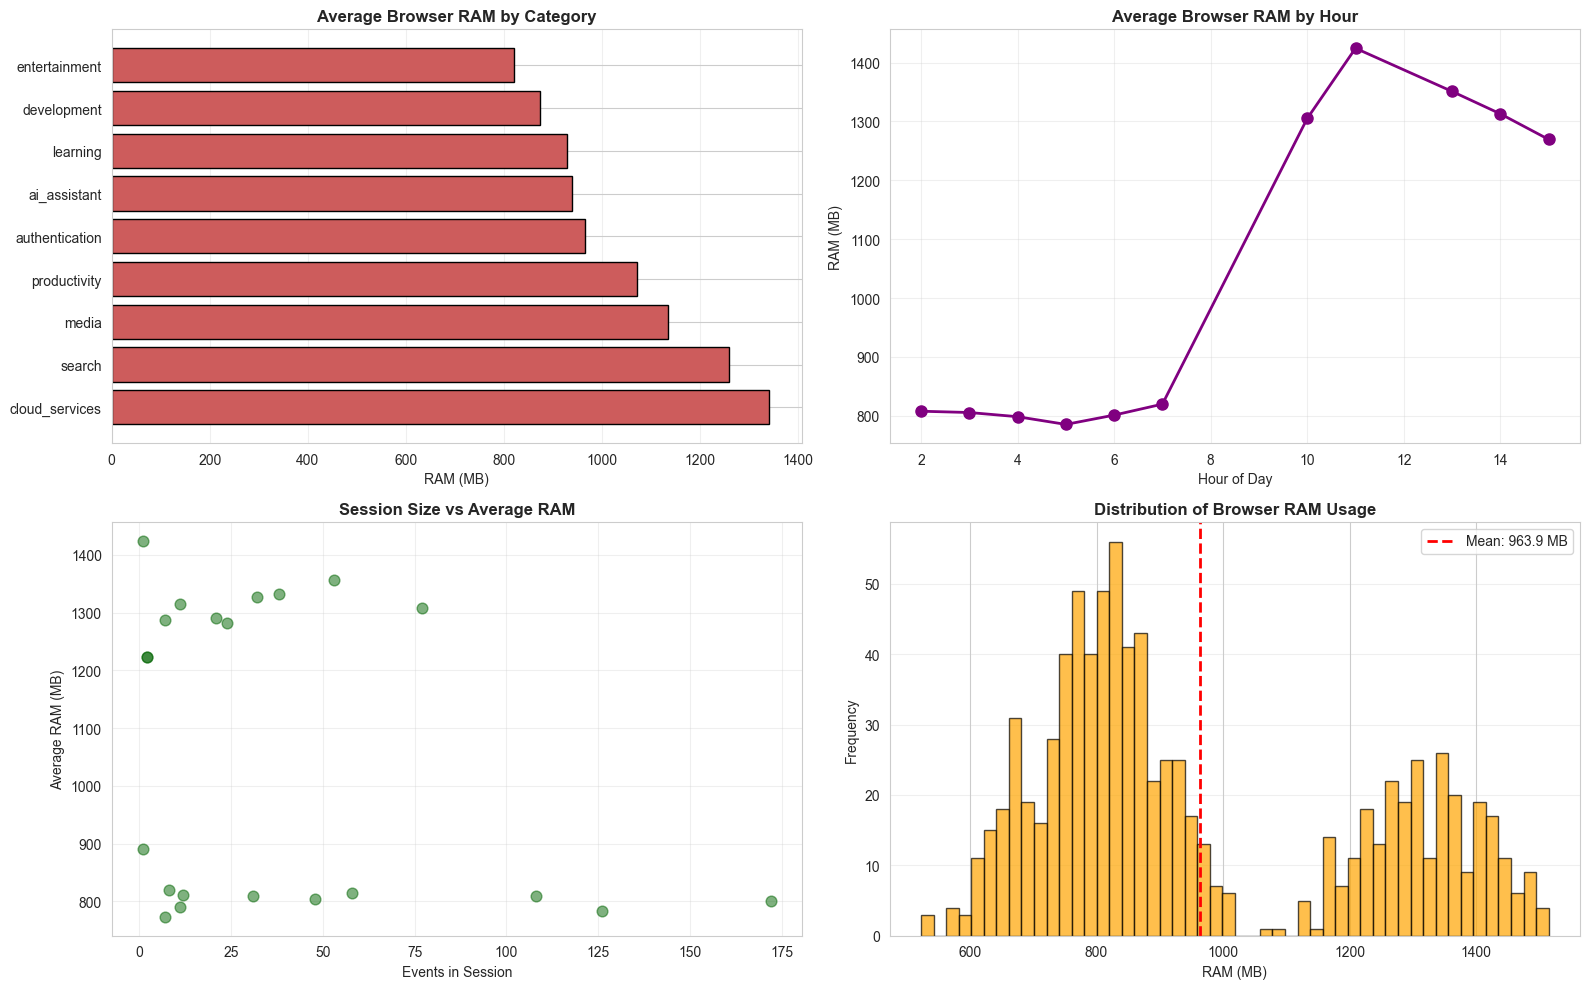


✓ RAM correlation analysis saved to OUTPUT/ram_correlation_analysis.png


In [10]:
def merge_with_ram(browsing_df, ram_df):
    """
    Merge browsing events with RAM logs using nearest timestamp join
    """
    browsing_sorted = browsing_df.sort_values('timestamp').reset_index(drop=True)
    ram_sorted = ram_df.sort_values('timestamp').reset_index(drop=True)
    
    merged = pd.merge_asof(
        browsing_sorted,
        ram_sorted,
        on='timestamp',
        direction='nearest',
        tolerance=pd.Timedelta('30s')  # Max 30 second difference
    )
    
    return merged


browsing_with_ram = merge_with_ram(browsing_df, ram_df)

print(f"✓ Merged data: {len(browsing_with_ram)} records")
print(f"✓ Records with RAM data: {browsing_with_ram['ram_used_mb'].notna().sum()}")

ram_by_category = browsing_with_ram.groupby('category').agg({
    'ram_used_mb': ['mean', 'max', 'std'],
    'browser_ram_mb': ['mean', 'max', 'std'],
    'timestamp': 'count'
}).round(2)

ram_by_category.columns = ['ram_mean', 'ram_max', 'ram_std', 
                           'browser_ram_mean', 'browser_ram_max', 'browser_ram_std',
                           'event_count']

print("\n" + "="*80)
print("RAM USAGE BY CATEGORY")
print("="*80)
print(ram_by_category.sort_values('browser_ram_mean', ascending=False))

ram_by_category.to_csv('OUTPUT/ram_by_category.csv')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ram_sorted = ram_by_category.sort_values('browser_ram_mean', ascending=False)
axes[0, 0].barh(range(len(ram_sorted)), ram_sorted['browser_ram_mean'], color='indianred', edgecolor='black')
axes[0, 0].set_yticks(range(len(ram_sorted)))
axes[0, 0].set_yticklabels(ram_sorted.index)
axes[0, 0].set_title('Average Browser RAM by Category', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('RAM (MB)')
axes[0, 0].grid(axis='x', alpha=0.3)

hourly_ram = browsing_with_ram.groupby('hour')['browser_ram_mb'].mean()
axes[0, 1].plot(hourly_ram.index, hourly_ram.values, marker='o', color='purple', linewidth=2, markersize=8)
axes[0, 1].set_title('Average Browser RAM by Hour', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('RAM (MB)')
axes[0, 1].grid(True, alpha=0.3)

session_ram = browsing_with_ram.groupby('session_id').agg({
    'browser_ram_mb': ['mean', 'max'],
    'timestamp': 'count'
}).reset_index()
session_ram.columns = ['session_id', 'avg_ram', 'max_ram', 'event_count']

axes[1, 0].scatter(session_ram['event_count'], session_ram['avg_ram'], 
                  alpha=0.5, color='darkgreen', s=60)
axes[1, 0].set_title('Session Size vs Average RAM', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Events in Session')
axes[1, 0].set_ylabel('Average RAM (MB)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(browsing_with_ram['browser_ram_mb'].dropna(), 
               bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(browsing_with_ram['browser_ram_mb'].mean(), 
                   color='red', linestyle='--', linewidth=2, label=f'Mean: {browsing_with_ram["browser_ram_mb"].mean():.1f} MB')
axes[1, 1].set_title('Distribution of Browser RAM Usage', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('RAM (MB)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('OUTPUT/ram_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ RAM correlation analysis saved to OUTPUT/ram_correlation_analysis.png")

### Add RAM Features to Sessions

In [11]:
session_ram_stats = browsing_with_ram.groupby('session_id').agg({
    'ram_used_mb': ['mean', 'max', 'std'],
    'browser_ram_mb': ['mean', 'max', 'std']
}).reset_index()

session_ram_stats.columns = ['session_id', 'ram_mean', 'ram_max', 'ram_std',
                             'browser_ram_mean', 'browser_ram_max', 'browser_ram_std']

session_features_df = session_features_df.merge(session_ram_stats, on='session_id', how='left')

print("✓ RAM features added to session data")
print("\nSession features with RAM:")
print(session_features_df[['session_id', 'total_events', 'dominant_category', 
                           'browser_ram_mean', 'browser_ram_max']].head(10))

✓ RAM features added to session data

Session features with RAM:
   session_id  total_events dominant_category  browser_ram_mean  \
0           1             2          learning       1222.470000   
1           2            77          learning       1307.849351   
2           3             2            search       1223.160000   
3           4            58          learning        815.313621   
4           5           126          learning        782.677698   
5           6            48          learning        803.876042   
6           7            24             media       1281.271667   
7           8             1      ai_assistant       1424.230000   
8           9            21            search       1289.768095   
9          10            11            search       1314.947273   

   browser_ram_max  
0          1286.17  
1          1500.34  
2          1223.16  
3          1016.59  
4          1067.07  
5           965.54  
6          1444.26  
7          1424.23  
8       

## Clustering (Unsupervised Learning)



In [12]:
clustering_features = [
    'duration_minutes', 'total_events', 'unique_domains',
    'events_per_minute', 'domain_switching_rate',
    'learning_ratio', 'development_ratio', 'ai_assistant_ratio',
    'cloud_services_ratio', 'productivity_ratio', 'media_ratio',
    'entertainment_ratio', 'search_ratio',
    'hour', 'day_num', 'browser_ram_mean', 'browser_ram_max'
]

sessions_for_clustering = session_features_df[clustering_features].dropna()

print(f"✓ Sessions for clustering: {len(sessions_for_clustering)}")
print(f"✓ Features used: {len(clustering_features)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(sessions_for_clustering)

print("\n✓ Features standardized!")

✓ Sessions for clustering: 22
✓ Features used: 17

✓ Features standardized!


Finding optimal number of clusters...


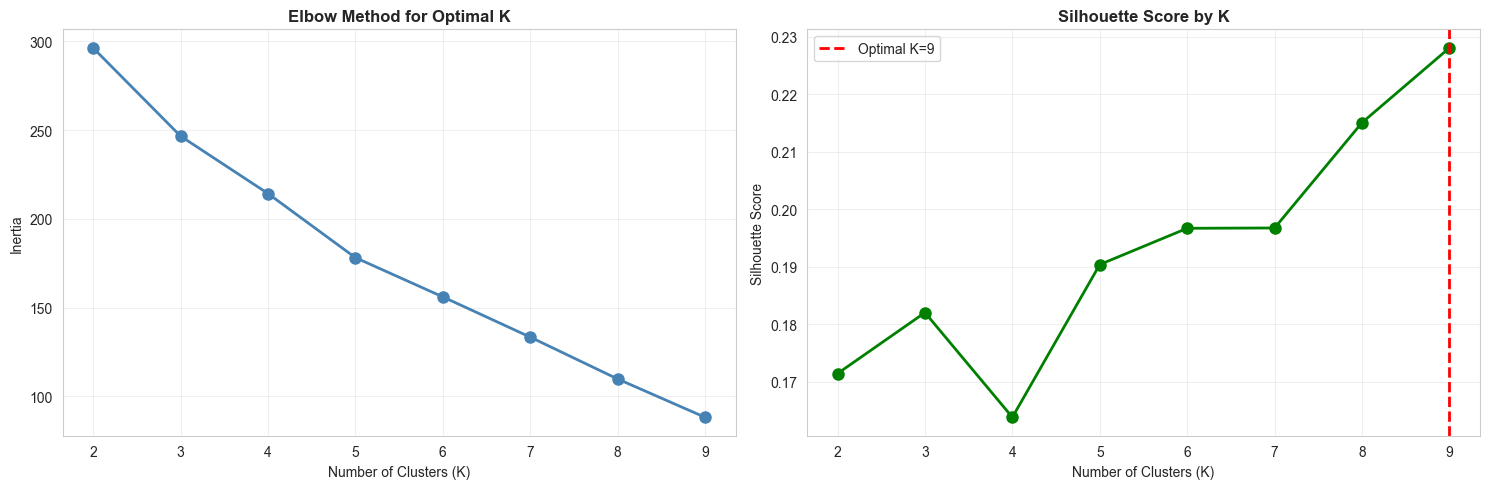


✓ Optimal number of clusters: 9
✓ Silhouette score: 0.228


In [13]:
inertias = []
silhouette_scores = []
K_range = range(2, 10)

print("Finding optimal number of clusters...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_title('Elbow Method for Optimal K', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='o', color='green', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score by K', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

optimal_k = K_range[np.argmax(silhouette_scores)]
axes[1].axvline(optimal_k, color='red', linestyle='--', linewidth=2, 
               label=f'Optimal K={optimal_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('OUTPUT/clustering_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Optimal number of clusters: {optimal_k}")
print(f"✓ Silhouette score: {max(silhouette_scores):.3f}")

In [14]:
n_clusters = optimal_k
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

sessions_for_clustering['cluster'] = cluster_labels
session_features_df.loc[sessions_for_clustering.index, 'cluster'] = cluster_labels

print(f"✓ Clustering complete!")
print(f"\nCluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

✓ Clustering complete!

Cluster distribution:
0    4
1    3
2    2
3    2
4    1
5    4
6    1
7    2
8    3
Name: count, dtype: int64


###  Cluster Interpretation

In [15]:
def interpret_clusters(df, cluster_col='cluster'):
    """
    Interpret and label clusters based on dominant characteristics
    """
    cluster_profiles = {}
    
    for cluster_id in sorted(df[cluster_col].dropna().unique()):
        cluster_data = df[df[cluster_col] == cluster_id]
        
        profile = {
            'count': len(cluster_data),
            'avg_duration': cluster_data['duration_minutes'].mean(),
            'avg_events': cluster_data['total_events'].mean(),
            'avg_ram': cluster_data['browser_ram_mean'].mean(),
            'peak_hour': cluster_data['hour'].mode()[0] if len(cluster_data['hour'].mode()) > 0 else 0,
        }
        
        category_cols = [col for col in df.columns if col.endswith('_ratio')]
        category_means = cluster_data[category_cols].mean()
        dominant_cat = category_means.idxmax().replace('_ratio', '')
        profile['dominant_category'] = dominant_cat
        profile['category_strength'] = category_means.max()
        
        if profile['avg_ram'] > df['browser_ram_mean'].quantile(0.75):
            ram_label = "Heavy RAM"
        elif profile['avg_ram'] < df['browser_ram_mean'].quantile(0.25):
            ram_label = "Light RAM"
        else:
            ram_label = "Moderate RAM"
        
        if profile['avg_duration'] > df['duration_minutes'].quantile(0.75):
            duration_label = "Long"
        elif profile['avg_duration'] < df['duration_minutes'].quantile(0.25):
            duration_label = "Short"
        else:
            duration_label = "Medium"
        
        profile['label'] = f"{duration_label} {dominant_cat.capitalize()} Session ({ram_label})"
        
        cluster_profiles[int(cluster_id)] = profile
    
    return cluster_profiles


cluster_profiles = interpret_clusters(session_features_df)

print("\n" + "="*80)
print("CLUSTER INTERPRETATION")
print("="*80)

for cluster_id, profile in cluster_profiles.items():
    print(f"\nCluster {cluster_id}: {profile['label']}")
    print(f"  Sessions: {profile['count']}")
    print(f"  Average duration: {profile['avg_duration']:.1f} minutes")
    print(f"  Average events: {profile['avg_events']:.1f}")
    print(f"  Average browser RAM: {profile['avg_ram']:.1f} MB")
    print(f"  Peak hour: {profile['peak_hour']}:00")
    print(f"  Dominant category: {profile['dominant_category']} ({profile['category_strength']:.1%})")


pd.DataFrame(cluster_profiles).T.to_csv('OUTPUT/cluster_profiles.csv')
print("\n✓ Cluster profiles saved to OUTPUT/cluster_profiles.csv")


CLUSTER INTERPRETATION

Cluster 0: Medium Search Session (Moderate RAM)
  Sessions: 4
  Average duration: 17.7 minutes
  Average events: 10.2
  Average browser RAM: 1278.6 MB
  Peak hour: 10:00
  Dominant category: search (84.6%)

Cluster 1: Medium Learning Session (Moderate RAM)
  Sessions: 3
  Average duration: 18.8 minutes
  Average events: 32.3
  Average browser RAM: 815.0 MB
  Peak hour: 3:00
  Dominant category: learning (87.5%)

Cluster 2: Short Entertainment Session (Moderate RAM)
  Sessions: 2
  Average duration: 0.4 minutes
  Average events: 4.0
  Average browser RAM: 831.5 MB
  Peak hour: 5:00
  Dominant category: entertainment (78.6%)

Cluster 3: Medium Learning Session (Light RAM)
  Sessions: 2
  Average duration: 24.1 minutes
  Average events: 29.5
  Average browser RAM: 796.7 MB
  Peak hour: 6:00
  Dominant category: learning (40.4%)

Cluster 4: Long Learning Session (Heavy RAM)
  Sessions: 1
  Average duration: 27.9 minutes
  Average events: 77.0
  Average browser RAM:

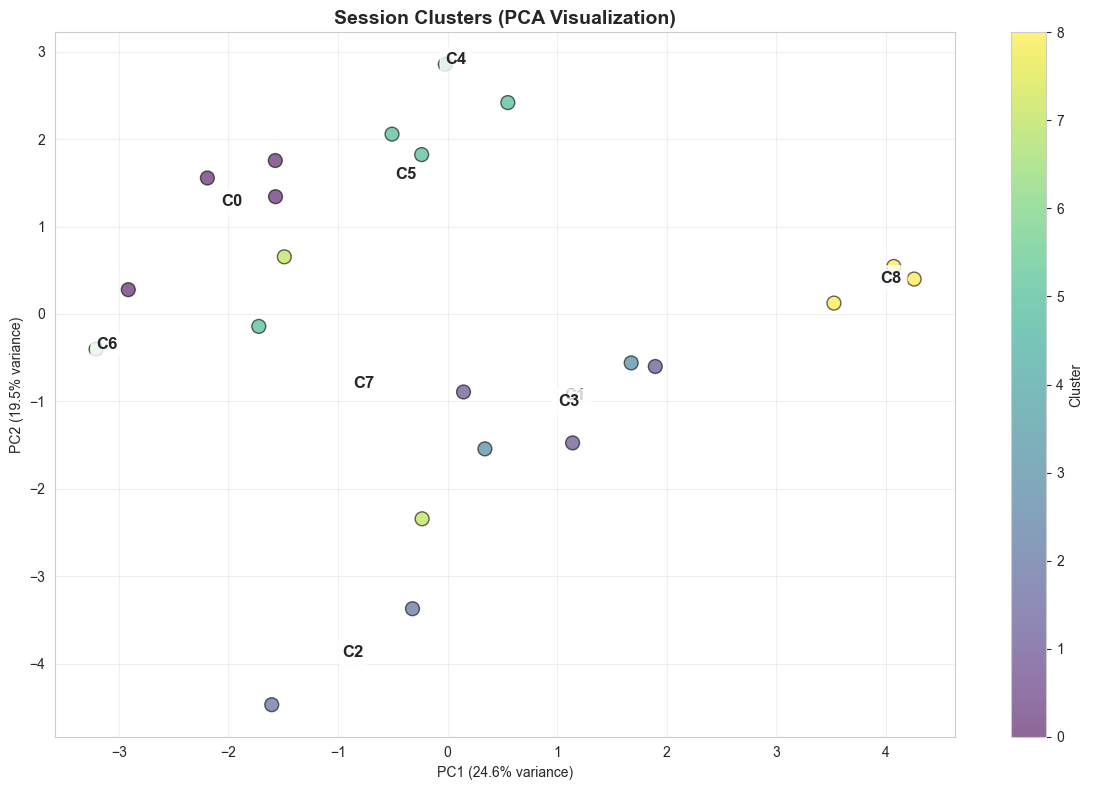

✓ Cluster visualization saved to OUTPUT/cluster_visualization.png


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=cluster_labels, cmap='viridis', 
                     s=100, alpha=0.6, edgecolors='black')
plt.colorbar(scatter, label='Cluster')
plt.title('Session Clusters (PCA Visualization)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, alpha=0.3)

for cluster_id in cluster_profiles.keys():
    cluster_center = X_pca[cluster_labels == cluster_id].mean(axis=0)
    plt.annotate(f'C{cluster_id}', xy=cluster_center, 
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('OUTPUT/cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Cluster visualization saved to OUTPUT/cluster_visualization.png")

## Deep Learning - Autoencoder for Anomaly Detection



In [19]:
X_autoencoder = X_scaled.copy()

print(f"✓ Data prepared for autoencoder: {X_autoencoder.shape}")
print(f"  Number of samples: {X_autoencoder.shape[0]}")
print(f"  Number of features: {X_autoencoder.shape[1]}")

✓ Data prepared for autoencoder: (22, 17)
  Number of samples: 22
  Number of features: 17


In [20]:
def build_autoencoder(input_dim, encoding_dim=8):
    """
    Build autoencoder model for anomaly detection
    
    Architecture:
    - Encoder: input_dim -> 32 -> 16 -> encoding_dim
    - Decoder: encoding_dim -> 16 -> 32 -> input_dim
    """
    # Encoder
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(32, activation='relu')(input_layer)
    encoded = Dropout(0.2)(encoded)
    encoded = Dense(16, activation='relu')(encoded)
    encoded = Dense(encoding_dim, activation='relu', name='encoding')(encoded)
    
    # Decoder
    decoded = Dense(16, activation='relu')(encoded)
    decoded = Dense(32, activation='relu')(decoded)
    decoded = Dropout(0.2)(decoded)
    decoded = Dense(input_dim, activation='linear')(decoded)
    
    # Autoencoder model
    autoencoder = Model(input_layer, decoded, name='autoencoder')
    autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return autoencoder


input_dim = X_autoencoder.shape[1]
autoencoder = build_autoencoder(input_dim, encoding_dim=8)

print("\n" + "="*80)
print("AUTOENCODER MODEL ARCHITECTURE")
print("="*80)
autoencoder.summary()
print("="*80)


AUTOENCODER MODEL ARCHITECTURE


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoding (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 17)             │           561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,489 (9.72 KB)

 Trainable params: 2,489 (9.72 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
print("\nTraining Autoencoder...\n")

history = autoencoder.fit(
    X_autoencoder, X_autoencoder,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

print("\n✓ Training complete!")

autoencoder.save('OUTPUT/autoencoder_model.h5')
print("✓ Model saved to OUTPUT/autoencoder_model.h5")


Training Autoencoder...

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.9636 - mae: 0.7103 - val_loss: 1.1608 - val_mae: 0.8178
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - loss: 0.9383 - mae: 0.7037 - val_loss: 1.1621 - val_mae: 0.8196
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - loss: 0.9452 - mae: 0.7023 - val_loss: 1.1637 - val_mae: 0.8210
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - loss: 0.9377 - mae: 0.7032 - val_loss: 1.1651 - val_mae: 0.8223
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - loss: 0.9451 - mae: 0.7076 - val_loss: 1.1665 - val_mae: 0.8235
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 0.9286 - mae: 0.6971 - val_loss: 1.1680 - val_mae: 0.8246



✓ Training complete!
✓ Model saved to OUTPUT/autoencoder_model.h5


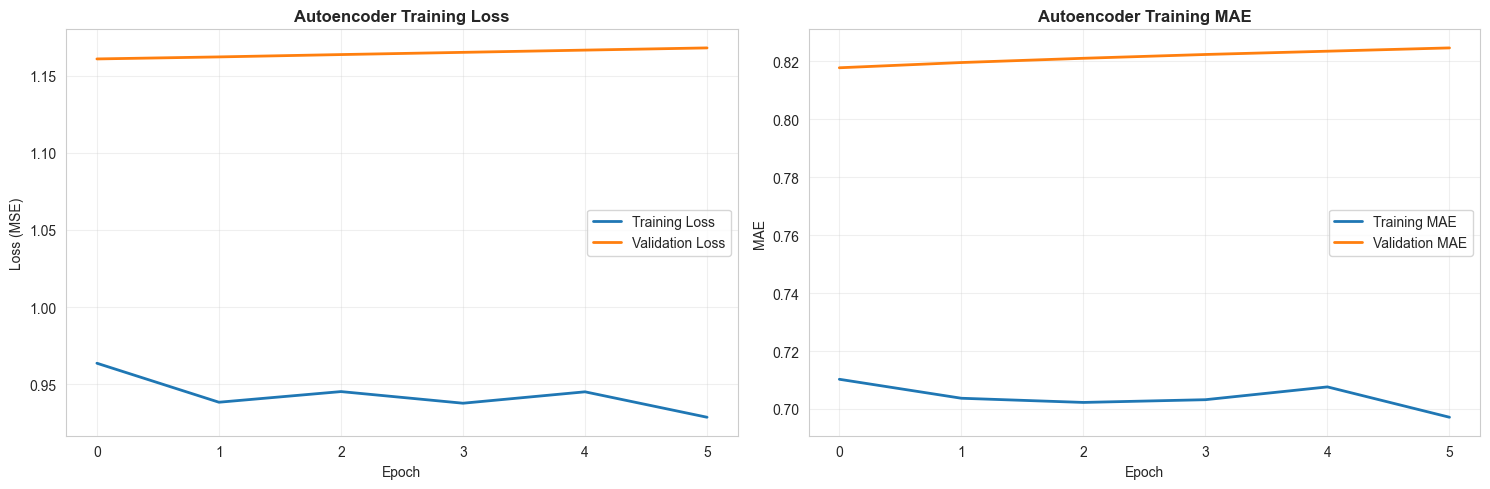

✓ Training history saved to OUTPUT/autoencoder_training.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Autoencoder Training Loss', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('Autoencoder Training MAE', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('OUTPUT/autoencoder_training.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training history saved to OUTPUT/autoencoder_training.png")

### Anomaly Detection

In [23]:

print("Calculating reconstruction errors...")
reconstructions = autoencoder.predict(X_autoencoder, verbose=0)
reconstruction_errors = np.mean(np.square(X_autoencoder - reconstructions), axis=1)

print(f"\n✓ Reconstruction errors calculated")
print(f"  Mean error: {reconstruction_errors.mean():.6f}")
print(f"  Std error: {reconstruction_errors.std():.6f}")
print(f"  Min error: {reconstruction_errors.min():.6f}")
print(f"  Max error: {reconstruction_errors.max():.6f}")


threshold = np.percentile(reconstruction_errors, 95)
print(f"\n✓ Anomaly threshold (95th percentile): {threshold:.6f}")

anomalies = reconstruction_errors > threshold
num_anomalies = anomalies.sum()
pct_anomalies = (num_anomalies / len(anomalies)) * 100

print(f"\n✓ Anomalies detected: {num_anomalies} sessions ({pct_anomalies:.1f}%)")

session_features_df.loc[sessions_for_clustering.index, 'anomaly_score'] = reconstruction_errors
session_features_df.loc[sessions_for_clustering.index, 'is_anomaly'] = anomalies

print("\n✓ Anomaly scores added to session features")

Calculating reconstruction errors...

✓ Reconstruction errors calculated
  Mean error: 0.993508
  Std error: 0.491152
  Min error: 0.399791
  Max error: 1.860812

✓ Anomaly threshold (95th percentile): 1.842965

✓ Anomalies detected: 2 sessions (9.1%)

✓ Anomaly scores added to session features


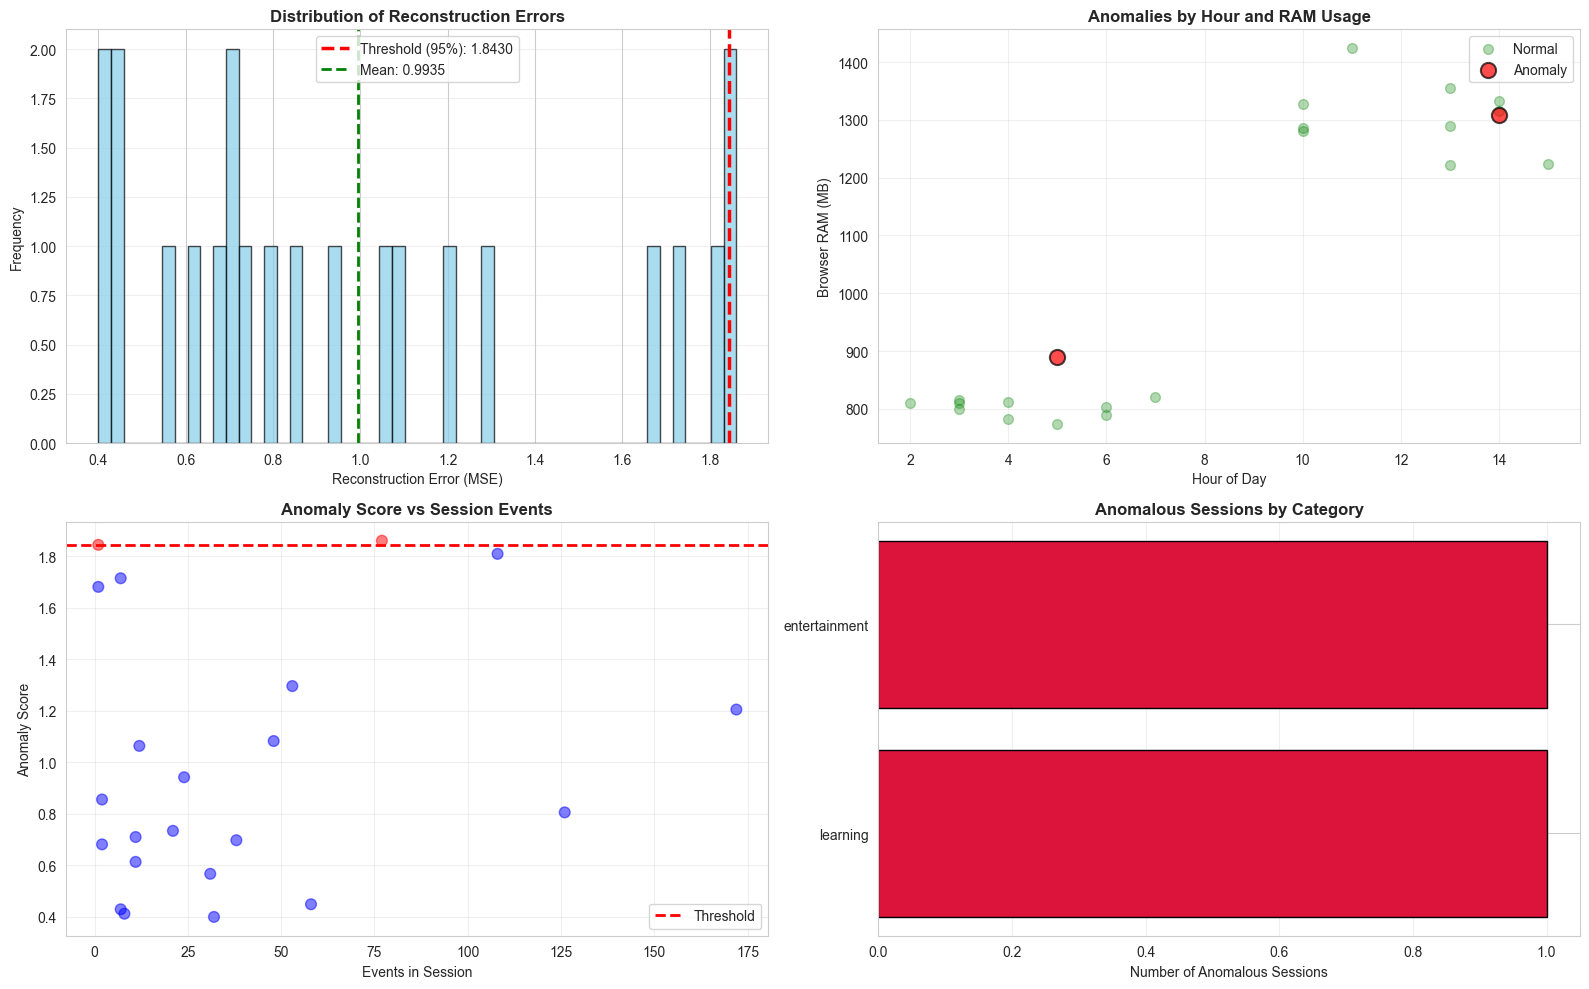

✓ Anomaly detection results saved to OUTPUT/anomaly_detection_results.png


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Reconstruction error distribution
axes[0, 0].hist(reconstruction_errors, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(threshold, color='red', linestyle='--', linewidth=2.5, 
                   label=f'Threshold (95%): {threshold:.4f}')
axes[0, 0].axvline(reconstruction_errors.mean(), color='green', linestyle='--', linewidth=2,
                   label=f'Mean: {reconstruction_errors.mean():.4f}')
axes[0, 0].set_title('Distribution of Reconstruction Errors', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Reconstruction Error (MSE)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Anomalies by hour and RAM
anomaly_sessions = session_features_df[session_features_df['is_anomaly'] == True]
normal_sessions = session_features_df[session_features_df['is_anomaly'] == False]

if len(normal_sessions) > 0:
    axes[0, 1].scatter(normal_sessions['hour'], normal_sessions['browser_ram_mean'], 
                      color='green', label='Normal', s=50, alpha=0.3)
if len(anomaly_sessions) > 0:
    axes[0, 1].scatter(anomaly_sessions['hour'], anomaly_sessions['browser_ram_mean'], 
                      color='red', label='Anomaly', s=120, alpha=0.7, edgecolors='black', linewidth=1.5)
axes[0, 1].set_title('Anomalies by Hour and RAM Usage', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Browser RAM (MB)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

valid_scores = session_features_df.dropna(subset=['anomaly_score'])
colors = ['red' if a else 'blue' for a in valid_scores['is_anomaly']]
axes[1, 0].scatter(valid_scores['total_events'], valid_scores['anomaly_score'], 
                  c=colors, alpha=0.5, s=60)
axes[1, 0].axhline(threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1, 0].set_title('Anomaly Score vs Session Events', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Events in Session')
axes[1, 0].set_ylabel('Anomaly Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

if len(anomaly_sessions) > 0:
    anomaly_cats = anomaly_sessions['dominant_category'].value_counts()
    axes[1, 1].barh(range(len(anomaly_cats)), anomaly_cats.values, color='crimson', edgecolor='black')
    axes[1, 1].set_yticks(range(len(anomaly_cats)))
    axes[1, 1].set_yticklabels(anomaly_cats.index)
    axes[1, 1].set_title('Anomalous Sessions by Category', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Number of Anomalous Sessions')
    axes[1, 1].grid(axis='x', alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No anomalies detected', 
                   ha='center', va='center', fontsize=14)
    axes[1, 1].set_title('Anomalous Sessions by Category', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('OUTPUT/anomaly_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Anomaly detection results saved to OUTPUT/anomaly_detection_results.png")

###  Analyze Anomalous Sessions

In [25]:
print("\n" + "="*80)
print("ANOMALY ANALYSIS - TOP UNUSUAL SESSIONS")
print("="*80)

if len(anomaly_sessions) > 0:
    top_anomalies = session_features_df.nlargest(10, 'anomaly_score')
    
    for idx, (i, row) in enumerate(top_anomalies.iterrows(), 1):
        print(f"\n{idx}. Session {row['session_id']} - Anomaly Score: {row['anomaly_score']:.6f}")
        print(f"   {'─'*70}")
        print(f"   Duration: {row['duration_minutes']:.1f} minutes")
        print(f"   Events: {row['total_events']:.0f}")
        print(f"   Unique domains: {row['unique_domains']:.0f}")
        print(f"   Dominant category: {row['dominant_category']}")
        print(f"   Browser RAM: {row['browser_ram_mean']:.1f} MB (max: {row['browser_ram_max']:.1f} MB)")
        print(f"   Time: {row['start_time']} (Hour: {row['hour']}:00)")
        print(f"   Day: {row['day_of_week']}")
        
        ratio_cols = [c for c in row.index if c.endswith('_ratio')]
        ratios = row[ratio_cols].sort_values(ascending=False).head(3)
        if len(ratios) > 0:
            print(f"   Top categories: ", end="")
            for cat, ratio in ratios.items():
                if ratio > 0:
                    print(f"{cat.replace('_ratio', '')}: {ratio:.1%}, ", end="")
            print()
    
    print("\n" + "="*80)
    print("ANOMALY SUMMARY STATISTICS")
    print("="*80)
    print(f"Total anomalies: {len(anomaly_sessions)}")
    print(f"Average duration: {anomaly_sessions['duration_minutes'].mean():.1f} minutes")
    print(f"Average events: {anomaly_sessions['total_events'].mean():.1f}")
    print(f"Average RAM: {anomaly_sessions['browser_ram_mean'].mean():.1f} MB")
    print(f"\nMost common anomaly hours: {anomaly_sessions['hour'].mode().values}")
    print(f"Most common anomaly day: {anomaly_sessions['day_of_week'].mode().values[0] if len(anomaly_sessions['day_of_week'].mode()) > 0 else 'N/A'}")
    
else:
    print("\nNo anomalies detected with current threshold.")
    print("All sessions appear to follow normal browsing patterns.")

if len(anomaly_sessions) > 0:
    anomaly_sessions.to_csv('OUTPUT/anomalous_sessions.csv', index=False)
    print("\n✓ Anomalous sessions saved to OUTPUT/anomalous_sessions.csv")


ANOMALY ANALYSIS - TOP UNUSUAL SESSIONS

1. Session 2 - Anomaly Score: 1.860812
   ──────────────────────────────────────────────────────────────────────
   Duration: 27.9 minutes
   Events: 77
   Unique domains: 7
   Dominant category: learning
   Browser RAM: 1307.8 MB (max: 1500.3 MB)
   Time: 2026-04-09 14:12:14.444375 (Hour: 14:00)
   Day: Thursday
   Top categories: learning: 59.7%, search: 23.4%, cloud_services: 14.3%, 

2. Session 21 - Anomaly Score: 1.844716
   ──────────────────────────────────────────────────────────────────────
   Duration: 0.0 minutes
   Events: 1
   Unique domains: 1
   Dominant category: entertainment
   Browser RAM: 889.9 MB (max: 889.9 MB)
   Time: 2026-04-14 05:42:53.643366 (Hour: 5:00)
   Day: Tuesday
   Top categories: entertainment: 100.0%, 

3. Session 11 - Anomaly Score: 1.809695
   ──────────────────────────────────────────────────────────────────────
   Duration: 57.7 minutes
   Events: 108
   Unique domains: 6
   Dominant category: developmen

## Recommendation Engine



In [26]:
def generate_recommendations(browsing_df, session_df, ram_by_category, anomaly_sessions):
    """
    Generate personalized recommendations based on YOUR browsing patterns
    """
    recommendations = []
    
    high_ram_categories = ram_by_category.nlargest(3, 'browser_ram_mean')
    if len(high_ram_categories) > 0:
        top_ram_cat = high_ram_categories.index[0]
        top_ram_value = high_ram_categories.iloc[0]['browser_ram_mean']
        recommendations.append({
            'category': 'Performance Optimization',
            'priority': 'High',
            'recommendation': f'Optimize {top_ram_cat} usage - close unused tabs or use lighter alternatives',
            'evidence': f'{top_ram_cat} category uses {top_ram_value:.0f} MB browser RAM on average',
            'metric': f'browser_ram_mean: {top_ram_value:.0f} MB'
        })
    
    learning_sessions = session_df[session_df['learning_ratio'] > 0.5]
    if len(learning_sessions) > 0:
        peak_learning_hour = learning_sessions['hour'].mode()[0] if len(learning_sessions['hour'].mode()) > 0 else 10
        recommendations.append({
            'category': 'Learning Optimization',
            'priority': 'Medium',
            'recommendation': f'Your peak learning time is around {peak_learning_hour}:00 - schedule important courses then',
            'evidence': f'{len(learning_sessions)} learning sessions, most active at hour {peak_learning_hour}',
            'metric': f'learning_sessions: {len(learning_sessions)}'
        })
    
    ai_sessions = session_df[session_df['ai_assistant_ratio'] > 0.3]
    if len(ai_sessions) > len(session_df) * 0.2:
        recommendations.append({
            'category': 'Productivity',
            'priority': 'Medium',
            'recommendation': 'High AI assistant usage detected - consider organizing prompts for efficiency',
            'evidence': f'{len(ai_sessions)} sessions with significant AI assistant usage',
            'metric': f'ai_assistant_sessions: {len(ai_sessions)}'
        })
    
    dev_sessions = session_df[session_df['development_ratio'] > 0.4]
    if len(dev_sessions) > 0:
        avg_dev_duration = dev_sessions['duration_minutes'].mean()
        recommendations.append({
            'category': 'Development Workflow',
            'priority': 'Medium',
            'recommendation': f'Development sessions average {avg_dev_duration:.1f} min - consider Pomodoro technique',
            'evidence': f'{len(dev_sessions)} development sessions analyzed',
            'metric': f'avg_dev_duration: {avg_dev_duration:.1f} minutes'
        })
    
    work_hours_sessions = session_df[(session_df['hour'] >= 9) & (session_df['hour'] <= 18)]
    if len(work_hours_sessions) > 0:
        entertainment_work = work_hours_sessions[work_hours_sessions['entertainment_ratio'] > 0.3]
        if len(entertainment_work) > 0:
            recommendations.append({
                'category': 'Focus & Discipline',
                'priority': 'High',
                'recommendation': 'Entertainment usage during study hours detected - use website blockers',
                'evidence': f'{len(entertainment_work)} work-hour sessions with entertainment content',
                'metric': f'entertainment_during_work: {len(entertainment_work)}'
            })
    
    long_sessions = session_df[session_df['duration_minutes'] > 60]
    if len(long_sessions) > 0:
        recommendations.append({
            'category': 'Health & Wellbeing',
            'priority': 'High',
            'recommendation': 'Take 5-10 minute breaks every hour to reduce eye strain and improve focus',
            'evidence': f'{len(long_sessions)} sessions exceeded 60 minutes without breaks',
            'metric': f'long_sessions: {len(long_sessions)}'
        })
    
    if len(anomaly_sessions) > 0:
        late_anomalies = anomaly_sessions[anomaly_sessions['hour'] >= 22]
        if len(late_anomalies) > 0:
            recommendations.append({
                'category': 'Sleep Hygiene',
                'priority': 'High',
                'recommendation': 'Unusual late-night browsing detected - maintain consistent sleep schedule',
                'evidence': f'{len(late_anomalies)} anomalous sessions after 10 PM',
                'metric': f'late_night_anomalies: {len(late_anomalies)}'
            })
    
    high_switching = session_df[session_df['domain_switching_rate'] > 0.7]
    if len(high_switching) > len(session_df) * 0.25:
        recommendations.append({
            'category': 'Focus Improvement',
            'priority': 'Medium',
            'recommendation': 'High tab switching detected - use tab grouping and management tools',
            'evidence': f'{len(high_switching)} sessions with >70% domain switching rate',
            'metric': f'high_switching_sessions: {len(high_switching)}'
        })
    
    avg_browser_ram = session_df['browser_ram_mean'].mean()
    if avg_browser_ram > 2000:
        recommendations.append({
            'category': 'Performance Optimization',
            'priority': 'High',
            'recommendation': 'High average browser RAM - enable memory saver mode or use lighter browser',
            'evidence': f'Average browser RAM usage is {avg_browser_ram:.0f} MB',
            'metric': f'avg_browser_ram: {avg_browser_ram:.0f} MB'
        })
    
    cloud_sessions = session_df[session_df['cloud_services_ratio'] > 0.3]
    if len(cloud_sessions) > 0:
        recommendations.append({
            'category': 'Cloud Services',
            'priority': 'Low',
            'recommendation': 'Regular AWS usage - ensure you monitor costs and resource usage',
            'evidence': f'{len(cloud_sessions)} sessions with AWS console activity',
            'metric': f'cloud_sessions: {len(cloud_sessions)}'
        })
    
    return recommendations


recommendations = generate_recommendations(
    browsing_df, 
    session_features_df, 
    ram_by_category,
    anomaly_sessions
)

print("\n" + "="*80)
print("PERSONALIZED RECOMMENDATIONS")
print("="*80)

priority_order = {'High': 1, 'Medium': 2, 'Low': 3}
recommendations_sorted = sorted(recommendations, key=lambda x: priority_order[x['priority']])

for i, rec in enumerate(recommendations_sorted, 1):
    print(f"\n{i}. [{rec['priority']} Priority] {rec['category']}")
    print(f"   {'─'*70}")
    print(f"   💡 {rec['recommendation']}")
    print(f"   📊 {rec['evidence']}")
    print(f"   📈 {rec['metric']}")

recommendations_df = pd.DataFrame(recommendations_sorted)
recommendations_df.to_csv('OUTPUT/recommendations.csv', index=False)
print("\n✓ Recommendations saved to OUTPUT/recommendations.csv")


PERSONALIZED RECOMMENDATIONS

1. [High Priority] Performance Optimization
   ──────────────────────────────────────────────────────────────────────
   💡 Optimize cloud_services usage - close unused tabs or use lighter alternatives
   📊 cloud_services category uses 1340 MB browser RAM on average
   📈 browser_ram_mean: 1340 MB

2. [High Priority] Health & Wellbeing
   ──────────────────────────────────────────────────────────────────────
   💡 Take 5-10 minute breaks every hour to reduce eye strain and improve focus
   📊 1 sessions exceeded 60 minutes without breaks
   📈 long_sessions: 1

3. [Medium Priority] Learning Optimization
   ──────────────────────────────────────────────────────────────────────
   💡 Your peak learning time is around 3:00 - schedule important courses then
   📊 9 learning sessions, most active at hour 3
   📈 learning_sessions: 9

4. [Medium Priority] Development Workflow
   ──────────────────────────────────────────────────────────────────────
   💡 Development ses

##  Final Summary Report

In [27]:
total_days = (browsing_df['timestamp'].max() - browsing_df['timestamp'].min()).days + 1
total_events = len(browsing_df)
total_sessions = browsing_df['session_id'].nunique()
unique_domains = browsing_df['domain'].nunique()

print("\n" + "="*80)
print("FINAL PROJECT SUMMARY REPORT")
print(f"Analysis Period: {total_days} days")
print("="*80)

print("\n1. DATA OVERVIEW")
print("   " + "─"*70)
print(f"   Total browsing events: {total_events:,}")
print(f"   Date range: {browsing_df['timestamp'].min()} to {browsing_df['timestamp'].max()}")
print(f"   Unique domains visited: {unique_domains}")
print(f"   Total sessions: {total_sessions}")
print(f"   RAM log entries: {len(ram_df):,}")

print("\n2. TOP 10 WEBSITES/DOMAINS")
print("   " + "─"*70)
top_domains = browsing_df['domain'].value_counts().head(10)
for rank, (domain, count) in enumerate(top_domains.items(), 1):
    pct = (count / total_events) * 100
    print(f"   {rank:2d}. {domain:40s} {count:4d} visits ({pct:5.1f}%)")

print("\n3. CATEGORY DISTRIBUTION")
print("   " + "─"*70)
category_dist = browsing_df['category'].value_counts()
for cat, count in category_dist.items():
    percentage = (count / len(browsing_df)) * 100
    print(f"   {cat:20s} {count:4d} ({percentage:5.1f}%)")

print("\n4. TIME-BASED PATTERNS")
print("   " + "─"*70)
peak_hour = browsing_df.groupby('hour').size().idxmax()
peak_day = browsing_df['day_of_week'].value_counts().index[0]
weekend_events = browsing_df['is_weekend'].sum()
print(f"   Peak browsing hour: {peak_hour:02d}:00")
print(f"   Most active day: {peak_day}")
print(f"   Weekend browsing: {weekend_events:,} events ({(weekend_events/len(browsing_df)*100):.1f}%)")
print(f"   Weekday browsing: {total_events - weekend_events:,} events ({((total_events - weekend_events)/len(browsing_df)*100):.1f}%)")

print("\n5. SESSION STATISTICS")
print("   " + "─"*70)
print(f"   Total sessions: {total_sessions}")
print(f"   Average session duration: {session_features_df['duration_minutes'].mean():.1f} minutes")
print(f"   Median session duration: {session_features_df['duration_minutes'].median():.1f} minutes")
print(f"   Average events per session: {session_features_df['total_events'].mean():.1f}")
print(f"   Average unique domains per session: {session_features_df['unique_domains'].mean():.1f}")

print("\n6. RAM CORRELATION FINDINGS")
print("   " + "─"*70)
print(f"   Average system RAM usage: {browsing_with_ram['ram_used_mb'].mean():.1f} MB")
print(f"   Average browser RAM usage: {browsing_with_ram['browser_ram_mb'].mean():.1f} MB")
print(f"   Peak browser RAM: {browsing_with_ram['browser_ram_mb'].max():.1f} MB")
print("\n   Top 3 memory-heavy categories:")
top_ram_cats = ram_by_category.nlargest(3, 'browser_ram_mean')
for rank, (cat, row) in enumerate(top_ram_cats.iterrows(), 1):
    print(f"   {rank}. {cat:20s} Avg: {row['browser_ram_mean']:6.1f} MB (Max: {row['browser_ram_max']:6.1f} MB)")

print("\n7. CLUSTERING RESULTS")
print("   " + "─"*70)
print(f"   Number of clusters identified: {len(cluster_profiles)}")
print(f"   Clustering quality (Silhouette): {max(silhouette_scores):.3f}")
print("\n   Cluster profiles:")
for cluster_id, profile in cluster_profiles.items():
    print(f"   Cluster {cluster_id}: {profile['label']}")
    print(f"      Sessions: {profile['count']}, Avg duration: {profile['avg_duration']:.1f} min, RAM: {profile['avg_ram']:.0f} MB")

print("\n8. ANOMALY DETECTION (AUTOENCODER) RESULTS")
print("   " + "─"*70)
print(f"   Model: Autoencoder with 8-dimensional encoding")
print(f"   Reconstruction threshold: {threshold:.6f}")
print(f"   Anomalies detected: {num_anomalies} sessions ({pct_anomalies:.1f}%)")
print(f"   Normal sessions: {len(anomalies) - num_anomalies} ({((len(anomalies) - num_anomalies)/len(anomalies)*100):.1f}%)")
if len(anomaly_sessions) > 0:
    print(f"\n   Anomaly characteristics:")
    print(f"   Average duration: {anomaly_sessions['duration_minutes'].mean():.1f} minutes")
    print(f"   Average RAM: {anomaly_sessions['browser_ram_mean'].mean():.1f} MB")
    print(f"   Most common hour: {anomaly_sessions['hour'].mode().values[0] if len(anomaly_sessions['hour'].mode()) > 0 else 'N/A'}")

print("\n9. TOP RECOMMENDATIONS (HIGH PRIORITY)")
print("   " + "─"*70)
high_priority = [r for r in recommendations_sorted if r['priority'] == 'High']
for i, rec in enumerate(high_priority[:5], 1):
    print(f"\n   {i}. {rec['recommendation']}")
    print(f"      → Evidence: {rec['evidence']}")

print("\n" + "="*80)
print("END OF REPORT")
print("="*80)

with open('OUTPUT/summary_report.txt', 'w') as f:
    f.write(f"BROWSING PATTERN ANALYSIS - FINAL REPORT\n")
    f.write(f"Analysis Period: {total_days} days\n")
    f.write(f"Generated: {datetime.now()}\n")
    f.write("="*80 + "\n\n")
    f.write(f"Total Events: {total_events:,}\n")
    f.write(f"Total Sessions: {total_sessions}\n")
    f.write(f"Unique Domains: {unique_domains}\n")
    f.write(f"Clusters: {len(cluster_profiles)}\n")
    f.write(f"Anomalies: {num_anomalies} ({pct_anomalies:.1f}%)\n")
    f.write(f"\nTop Category: {category_dist.index[0]}\n")
    f.write(f"Peak Hour: {peak_hour:02d}:00\n")
    f.write(f"Avg Browser RAM: {browsing_with_ram['browser_ram_mb'].mean():.1f} MB\n")

print("\n✓ Summary report saved to OUTPUT/summary_report.txt")


FINAL PROJECT SUMMARY REPORT
Analysis Period: 5 days

1. DATA OVERVIEW
   ──────────────────────────────────────────────────────────────────────
   Total browsing events: 850
   Date range: 2026-04-09 13:30:39.513788 to 2026-04-14 06:39:42.435872
   Unique domains visited: 20
   Total sessions: 22
   RAM log entries: 40,735

2. TOP 10 WEBSITES/DOMAINS
   ──────────────────────────────────────────────────────────────────────
    1. colab.research.google.com                 388 visits ( 45.6%)
    2. guvi.in                                   135 visits ( 15.9%)
    3. github.com                                 88 visits ( 10.4%)
    4. google.com                                 66 visits (  7.8%)
    5. claude.ai                                  29 visits (  3.4%)
    6. chatgpt.com                                29 visits (  3.4%)
    7. classify.zenclass.in                       22 visits (  2.6%)
    8. docs.google.com                            20 visits (  2.4%)
    9. v2.zenclass.

### Create Comprehensive Dashboard

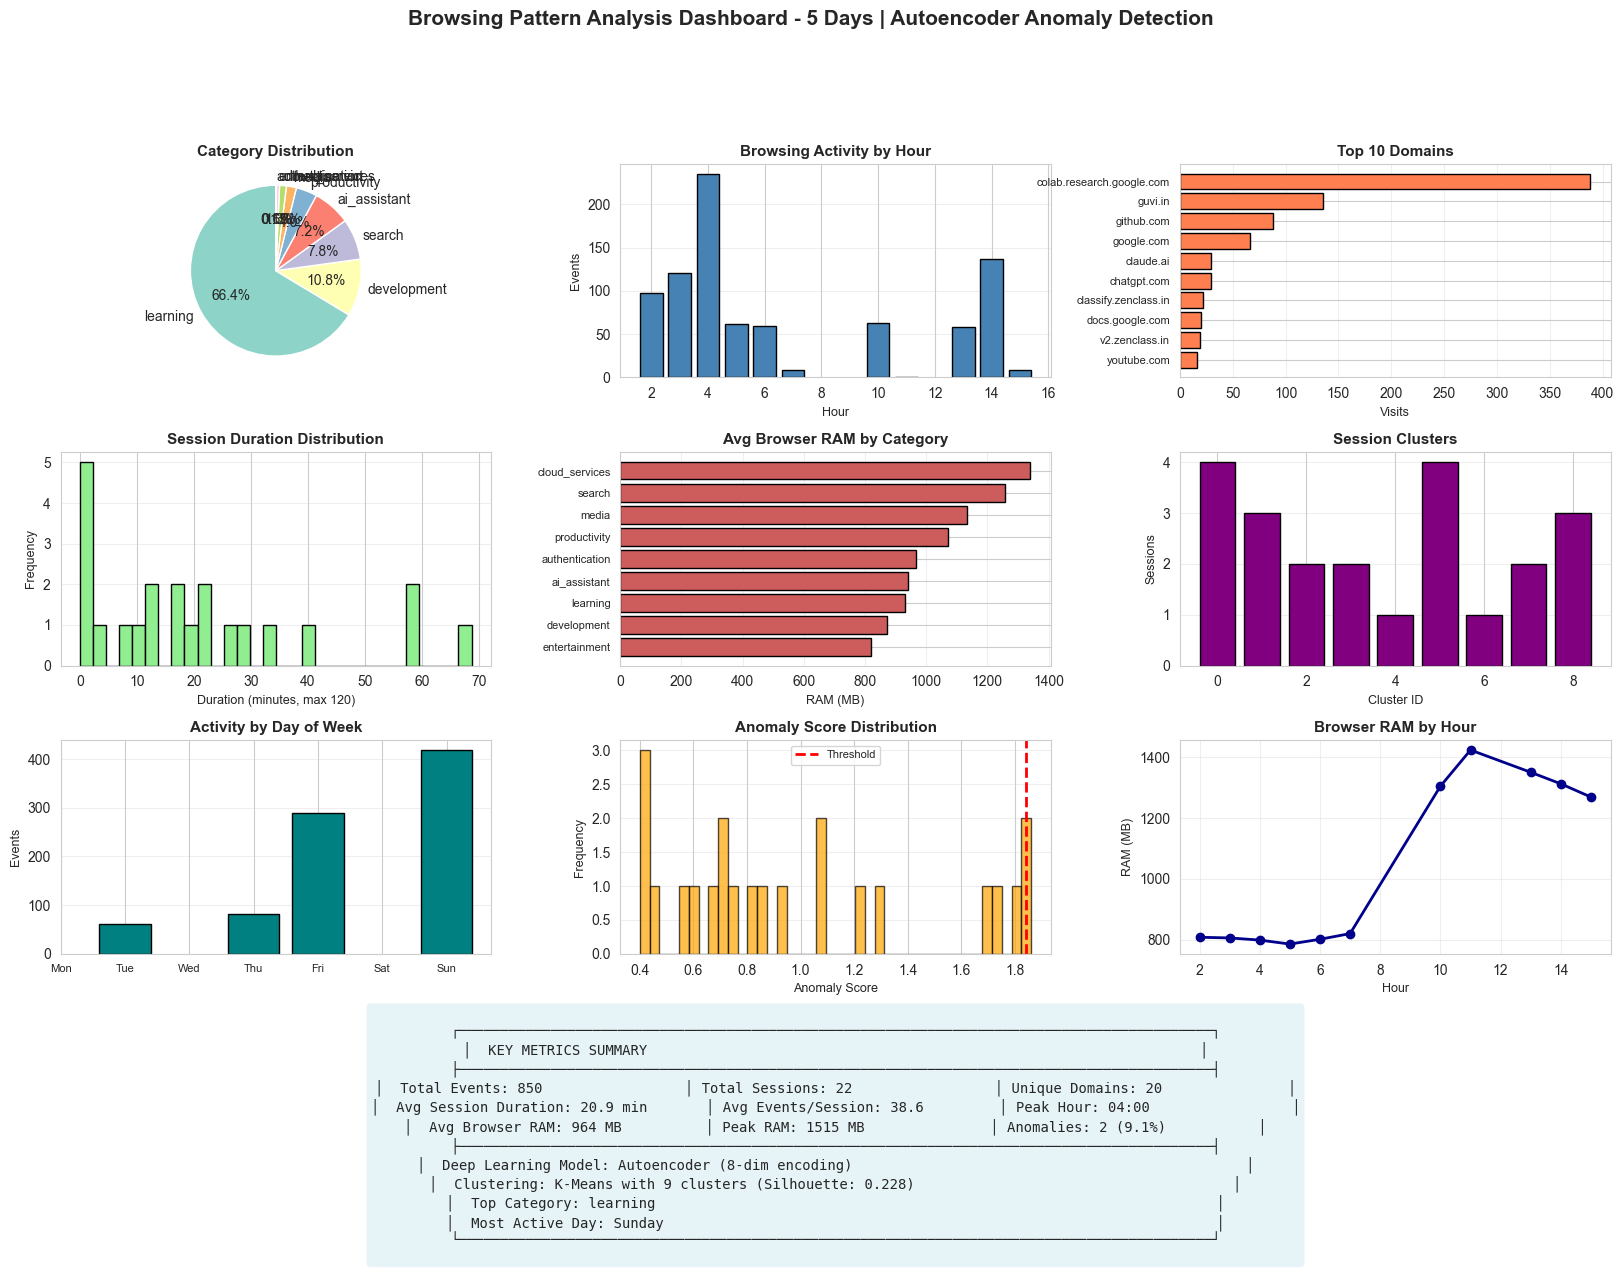


✓ Comprehensive dashboard saved to OUTPUT/comprehensive_dashboard.png


In [28]:
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
category_dist = browsing_df['category'].value_counts()
colors = plt.cm.Set3(range(len(category_dist)))
ax1.pie(category_dist.values, labels=category_dist.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title('Category Distribution', fontweight='bold', fontsize=11)

ax2 = fig.add_subplot(gs[0, 1])
hourly_counts = browsing_df.groupby('hour').size()
ax2.bar(hourly_counts.index, hourly_counts.values, color='steelblue', edgecolor='black')
ax2.set_title('Browsing Activity by Hour', fontweight='bold', fontsize=11)
ax2.set_xlabel('Hour', fontsize=9)
ax2.set_ylabel('Events', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
top_10_domains = browsing_df['domain'].value_counts().head(10)
ax3.barh(range(len(top_10_domains)), top_10_domains.values, color='coral', edgecolor='black')
ax3.set_yticks(range(len(top_10_domains)))
ax3.set_yticklabels(top_10_domains.index, fontsize=8)
ax3.set_title('Top 10 Domains', fontweight='bold', fontsize=11)
ax3.set_xlabel('Visits', fontsize=9)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
session_durations = session_features_df['duration_minutes'].clip(0, 120)
ax4.hist(session_durations, bins=30, color='lightgreen', edgecolor='black')
ax4.set_title('Session Duration Distribution', fontweight='bold', fontsize=11)
ax4.set_xlabel('Duration (minutes, max 120)', fontsize=9)
ax4.set_ylabel('Frequency', fontsize=9)
ax4.grid(axis='y', alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
ram_sorted = ram_by_category.sort_values('browser_ram_mean', ascending=True)
ax5.barh(range(len(ram_sorted)), ram_sorted['browser_ram_mean'], color='indianred', edgecolor='black')
ax5.set_yticks(range(len(ram_sorted)))
ax5.set_yticklabels(ram_sorted.index, fontsize=8)
ax5.set_title('Avg Browser RAM by Category', fontweight='bold', fontsize=11)
ax5.set_xlabel('RAM (MB)', fontsize=9)
ax5.grid(axis='x', alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
cluster_counts = session_features_df['cluster'].value_counts().sort_index()
ax6.bar(cluster_counts.index, cluster_counts.values, color='purple', edgecolor='black')
ax6.set_title('Session Clusters', fontweight='bold', fontsize=11)
ax6.set_xlabel('Cluster ID', fontsize=9)
ax6.set_ylabel('Sessions', fontsize=9)
ax6.grid(axis='y', alpha=0.3)

ax7 = fig.add_subplot(gs[2, 0])
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = browsing_df['day_of_week'].value_counts().reindex(day_order)
ax7.bar(range(7), day_counts.values, color='teal', edgecolor='black')
ax7.set_xticks(range(7))
ax7.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], fontsize=8)
ax7.set_title('Activity by Day of Week', fontweight='bold', fontsize=11)
ax7.set_ylabel('Events', fontsize=9)
ax7.grid(axis='y', alpha=0.3)

ax8 = fig.add_subplot(gs[2, 1])
if 'anomaly_score' in session_features_df.columns:
    anomaly_scores = session_features_df['anomaly_score'].dropna()
    ax8.hist(anomaly_scores, bins=40, color='orange', edgecolor='black', alpha=0.7)
    ax8.axvline(threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
    ax8.set_title('Anomaly Score Distribution', fontweight='bold', fontsize=11)
    ax8.set_xlabel('Anomaly Score', fontsize=9)
    ax8.set_ylabel('Frequency', fontsize=9)
    ax8.legend(fontsize=8)
    ax8.grid(axis='y', alpha=0.3)

ax9 = fig.add_subplot(gs[2, 2])
hourly_ram = browsing_with_ram.groupby('hour')['browser_ram_mb'].mean()
ax9.plot(hourly_ram.index, hourly_ram.values, marker='o', color='darkblue', linewidth=2, markersize=6)
ax9.set_title('Browser RAM by Hour', fontweight='bold', fontsize=11)
ax9.set_xlabel('Hour', fontsize=9)
ax9.set_ylabel('RAM (MB)', fontsize=9)
ax9.grid(True, alpha=0.3)

ax10 = fig.add_subplot(gs[3, :])
ax10.axis('off')

summary_text = f"""
┌{'─'*90}┐
│  KEY METRICS SUMMARY{' '*66}│
├{'─'*90}┤
│  Total Events: {total_events:,}{' '*(20-len(str(total_events)))}│ Total Sessions: {total_sessions}{' '*(19-len(str(total_sessions)))}│ Unique Domains: {unique_domains}{' '*(17-len(str(unique_domains)))}│
│  Avg Session Duration: {session_features_df['duration_minutes'].mean():.1f} min{' '*(7)}│ Avg Events/Session: {session_features_df['total_events'].mean():.1f}{' '*(9)}│ Peak Hour: {peak_hour:02d}:00{' '*(17)}│
│  Avg Browser RAM: {browsing_with_ram['browser_ram_mb'].mean():.0f} MB{' '*(10)}│ Peak RAM: {browsing_with_ram['browser_ram_mb'].max():.0f} MB{' '*(15)}│ Anomalies: {num_anomalies} ({pct_anomalies:.1f}%){' '*(11)}│
├{'─'*90}┤
│  Deep Learning Model: Autoencoder (8-dim encoding){' '*(47)}│
│  Clustering: K-Means with {len(cluster_profiles)} clusters (Silhouette: {max(silhouette_scores):.3f}){' '*(39-len(str(len(cluster_profiles))))}│
│  Top Category: {category_dist.index[0]}{' '*(75-len(category_dist.index[0]))}│
│  Most Active Day: {peak_day}{' '*(72-len(peak_day))}│
└{'─'*90}┘
"""

ax10.text(0.5, 0.5, summary_text, fontsize=10, family='monospace',
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.suptitle(f'Browsing Pattern Analysis Dashboard - {total_days} Days | Autoencoder Anomaly Detection', 
            fontsize=15, fontweight='bold', y=0.99)

plt.savefig('OUTPUT/comprehensive_dashboard.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n✓ Comprehensive dashboard saved to OUTPUT/comprehensive_dashboard.png")